# Assignment 4

Deadline: 13.05.2026, 12:00 CET

<Add your name, student-id and emal address>

In [2]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm    # for regression analysis in 1.c) (or any other regression library you prefer)

# Add the project root directory to Python path
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
src_path = os.path.join(project_root, "src")
if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [5]:
PATH_TO_DATA = '../data/'     # <change this to your path to data>
SAVE_PATH = '../backtests/'        # <change this to your path where you want to store the backtest>

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [6]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [7]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [21]:
JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

# 1) Profit Growth: short-term changes / surprises in profitability and sales.
JKP_FIELDS_PROFIT_GROWTH = [
    'niq_at_chg1',     # 1q-change in quarterly ROA
    'niq_be_chg1',     # 1q-change in quarterly ROE
    'ocf_at_chg1',     # 1q-change in operating cash flow / assets
    'tax_gr1a',        # tax expense growth (proxy for earnings growth)
    'ni_ar1',          # earnings persistence (AR(1) of net income)
]

# 2) Investment
JKP_FIELDS_INVESTMENT = [
    'capx_gr3',
    'emp_gr1',
]

# 3) Low Risk: betas and idiosyncratic / total return volatility.
JKP_FIELDS_LOW_RISK = [
    'beta_60m',
    'betadown_252d',
    'ivol_capm_21d',
    'ivol_capm_252d',
    'ivol_ff3_21d',
    'rvol_21d',
]


JKP_FIELDS = {
    'quality': JKP_FIELDS_QUALITY,
    'value': JKP_FIELDS_VALUE,
    'momentum': JKP_FIELDS_MOMENTUM,
    'profit_growth': JKP_FIELDS_PROFIT_GROWTH,
    'investment': JKP_FIELDS_INVESTMENT,
    'low_risk': JKP_FIELDS_LOW_RISK
}

## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.

- Simulate the return streams for both backtests and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

Starting Backtest Engine...

[QUALITY] Building BacktestService...
Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebal

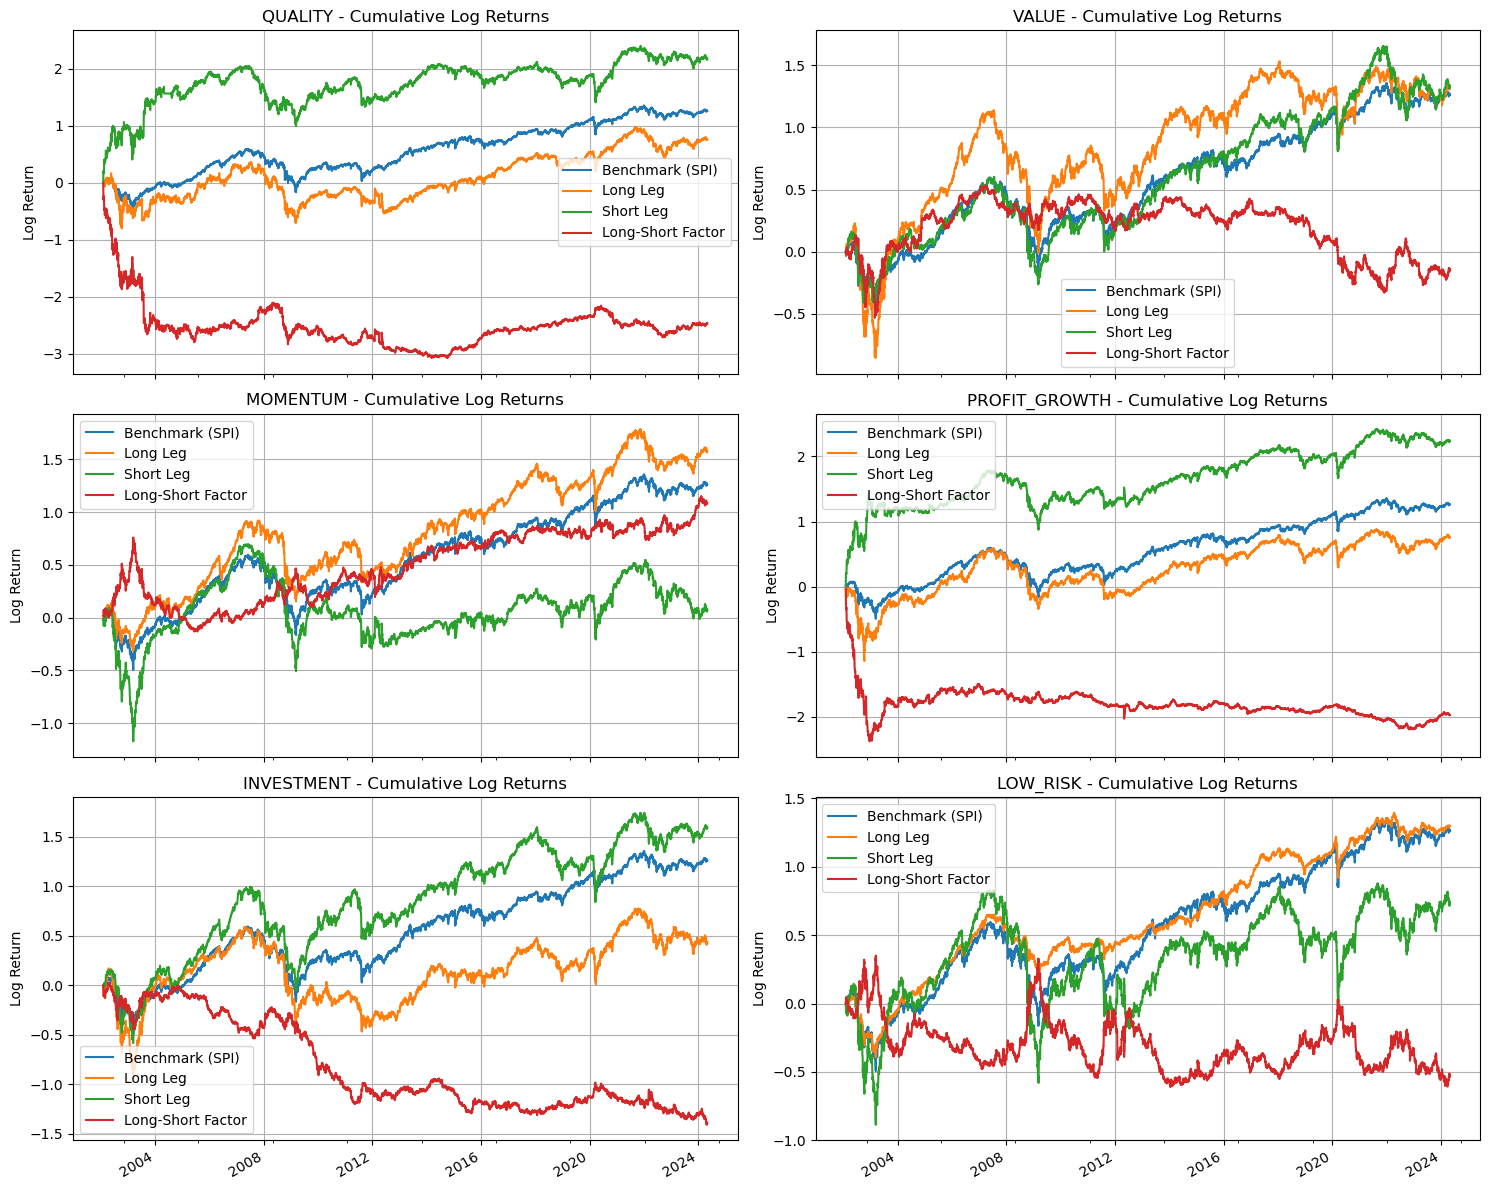


=== PERFORMANCE SUMMARY ===


Ann. Return  Ann. Volatility  Sharpe Ratio
Theme         Portfolio                                                    
QUALITY       Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0334           0.2597        0.2575
              Short Leg               0.0976           0.2766        0.4738
              Long-Short Factor      -0.1003           0.2851       -0.2253
VALUE         Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0583           0.2201        0.3679
              Short Leg               0.0584           0.1861        0.3983
              Long-Short Factor      -0.0060           0.1602        0.0428
MOMENTUM      Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0700           0.1748        0.4747
              Short Leg               0.0031           0.2067        0.1185
              Long-Short Factor       0.0476           0.1539        0.3797
PROFIT_GROWTH Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0330           0.2135        0.2590
              Short Leg               0.1010           0.2178        0.5492
              Long-Short Factor      -0.0812           0.1998       -0.3219
INVESTMENT    Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0185           0.2022        0.1920
              Short Leg               0.0709           0.1958        0.4483
              Long-Short Factor      -0.0580           0.1468       -0.3335
LOW_RISK      Benchmark (SPI)         0.0556           0.1647        0.4114
              Long Leg                0.0572           0.1044        0.5853
              Short Leg               0.0318           0.2533        0.2503
              Long-Short Factor      -0.0222           0.2003       -0.0115

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- HELPER FUNCTION: Calculate Performance Statistics ---
def compute_stats(returns, ann_factor=252):
    """Calculates annualized return, volatility, and Sharpe Ratio."""
    ret_clean = returns.dropna()
    if len(ret_clean) == 0:
        return np.nan, np.nan, np.nan
    
    ann_return = (1 + ret_clean).prod() ** (ann_factor / len(ret_clean)) - 1
    ann_vol = ret_clean.std() * np.sqrt(ann_factor)
    sharpe = (ret_clean.mean() / ret_clean.std()) * np.sqrt(ann_factor) if ret_clean.std() > 0 else np.nan
    
    return ann_return, ann_vol, sharpe

# 1. Initialize containers
factor_results = {}
stats_list = []

fixed_costs = 0
variable_costs = 0.002 # 20 bps

print("Starting Backtest Engine...\n")

for theme_name, theme_fields in JKP_FIELDS.items():
    print(f"[{theme_name.upper()}] Building BacktestService...")
    
    # Setup the BacktestService
    bs = make_backtest_service(theme_fields)
    return_series = bs.data.get_return_series(weekdays_only=False)
    
    # ---------------------------------------------------------
    # DYNAMIC THEME LOGIC (The "Low Risk" Flip)
    # ---------------------------------------------------------
    if theme_name == 'low_risk':
        # For risk, lower is better. Long the bottom 20%, Short the top 20%.
        long_pct, long_sign = 20, '<='
        short_pct, short_sign = 80, '>='
    else:
        # Standard: Long the top 20%, Short the bottom 20%
        long_pct, long_sign = 80, '>='
        short_pct, short_sign = 20, '<='

    # ---------------------------------------------------------
    # RUN BACKTESTS
    # ---------------------------------------------------------
    # Long Leg (Top Quintile)
    bs.optimization = PercentilePortfolio(percentile=long_pct, sign=long_sign)
    bt_long = Backtest()
    bt_long.run(bs=bs)
    
    # Short Leg (Bottom Quintile)
    bs.optimization = PercentilePortfolio(percentile=short_pct, sign=short_sign)
    bt_short = Backtest()
    bt_short.run(bs=bs)
    
    # ---------------------------------------------------------
    # SIMULATION & COMBINATION
    # ---------------------------------------------------------
    sim_long = bt_long.strategy.simulate(return_series=return_series, fc=fixed_costs, vc=variable_costs)
    sim_short = bt_short.strategy.simulate(return_series=return_series, fc=fixed_costs, vc=variable_costs)
    
    sim_df = pd.concat({
        'Benchmark (SPI)': bs.data.bm_series,
        'Long Leg': sim_long,
        'Short Leg': sim_short,
        'Long-Short Factor': sim_long - sim_short,
    }, axis=1).dropna()
    
    factor_results[theme_name] = sim_df

    # ---------------------------------------------------------
    # CALCULATE STATISTICS
    # ---------------------------------------------------------
    for col in sim_df.columns:
        ann_ret, ann_vol, sharpe = compute_stats(sim_df[col])
        stats_list.append({
            'Theme': theme_name.upper(),
            'Portfolio': col,
            'Ann. Return': ann_ret,
            'Ann. Volatility': ann_vol,
            'Sharpe Ratio': sharpe
        })

print("\n--- Backtests Complete ---")

# ---------------------------------------------------------
# GRID PLOTTING
# ---------------------------------------------------------
n_themes = len(factor_results)
# Calculate grid size (e.g., 6 themes -> 3 rows, 2 columns)
cols = 2
rows = int(np.ceil(n_themes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True)
axes = axes.flatten() # Flatten to make it easy to loop over

for i, (theme_name, sim_df) in enumerate(factor_results.items()):
    ax = axes[i]
    np.log((1 + sim_df)).cumsum().plot(ax=ax, grid=True)
    ax.set_title(f'{theme_name.upper()} - Cumulative Log Returns')
    ax.set_ylabel('Log Return')
    
# Hide any empty subplots if we have an odd number of themes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# DISPLAY STATISTICS
# ---------------------------------------------------------
stats_df = pd.DataFrame(stats_list).set_index(['Theme', 'Portfolio'])
print("\n=== PERFORMANCE SUMMARY ===")
display(stats_df.round(4))

## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix series and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [27]:
import statsmodels.api as sm
import pandas as pd

print("\nStarting Factor Analysis...")

# 1. Extract the daily series using positional indexing (.iloc) to bypass MultiIndex KeyErrors
top_quintiles_daily_dict = {}
ls_factors_daily_dict = {}

for theme, df in factor_results.items():
    # Col 1 is 'Long Leg', Col 3 is 'Long-Short Factor'
    # We use .squeeze() to ensure it forces it into a flat 1D Series
    top_quintiles_daily_dict[theme] = df.iloc[:, 1].squeeze()
    ls_factors_daily_dict[f"{theme}_LS"] = df.iloc[:, 3].squeeze()

top_quintiles_daily = pd.DataFrame(top_quintiles_daily_dict)
ls_factors_daily = pd.DataFrame(ls_factors_daily_dict)

# Col 0 is the Benchmark (SPI)
spi_daily = factor_results[list(factor_results.keys())[0]].iloc[:, 0].squeeze()

# 2. Compute the "factor-mix" return series (Average of the top-quintile portfolios)
factor_mix_daily = top_quintiles_daily.mean(axis=1)

# Force the index to be a proper DatetimeIndex so resample doesn't crash
factor_mix_daily.index = pd.to_datetime(factor_mix_daily.index)
spi_daily.index = pd.to_datetime(spi_daily.index)
ls_factors_daily.index = pd.to_datetime(ls_factors_daily.index)

# 3. Convert Daily Returns to Monthly Returns
def convert_to_monthly(daily_series):
    # Using 'ME' (Month End) which is the modern pandas standard, falling back to 'M' if needed
    try:
        return (1 + daily_series).resample('ME').prod() - 1
    except ValueError:
        return (1 + daily_series).resample('M').prod() - 1

y_monthly = convert_to_monthly(factor_mix_daily)
spi_monthly = convert_to_monthly(spi_daily)
ls_factors_monthly = convert_to_monthly(ls_factors_daily)

# 4. Construct Regression Variables (y and X)
y_monthly.name = 'Factor_Mix'

# X contains ii) the SPI return series and iii) the factor return series
X_monthly = pd.concat([spi_monthly.rename('SPI'), ls_factors_monthly], axis=1)

# X contains i) a constant
X_monthly = sm.add_constant(X_monthly)

# Align dates and drop any NaNs to prevent regression errors
reg_data = pd.concat([y_monthly, X_monthly], axis=1).dropna()
y_clean = reg_data['Factor_Mix']
X_clean = reg_data.drop(columns='Factor_Mix')

# 5. Run Ordinary Least Squares (OLS) Regression
model = sm.OLS(y_clean, X_clean).fit()

# Print the summary table
print("\n=== Regression Output ===")
print(model.summary())


Starting Factor Analysis...

=== Regression Output ===
                            OLS Regression Results                            
Dep. Variable:             Factor_Mix   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     72.11
Date:                Mon, 11 May 2026   Prob (F-statistic):           3.23e-57
Time:                        09:54:25   Log-Likelihood:                 628.46
No. Observations:                 267   AIC:                            -1241.
Df Residuals:                     259   BIC:                            -1212.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------